## Реализация линейной регресии

https://www.kaggle.com/code/mostov/diamonds-price-eda-and-regression

## Импорт библиотек


In [75]:
import warnings
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

In [76]:
warnings.filterwarnings("ignore")

## Загрузка датасета

In [77]:
df_origin = pd.read_csv('../data/diamonds.csv')

Набор данных содержит цены и другие атрибуты почти 54 000 бриллиантов.

Столбцы:

carat - Вес бриллианта в каратах (0,2-5,01)

cut - Качество огранки (Чистое, хорошее, очень хорошее, Премиум, Идеальное)

color - Цвет бриллианта от J (худший) до D (лучший)

clarity - Прозрачность - показатель чистоты алмаза (I1 (наихудший), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (наилучший))

depth  - Общая глубина в процентах = z / mean(x, y) = 2 * z / (x + y) (43--79)

table  - Ширина вершины ромба относительно самой широкой точки (43--95)

price  - Стоимость, указана в долларах США (от 326 до 18 823 долларов США).

x - Длина в мм (0--10,74)

y - Ширина в мм (0--58,9)

z - Глубина в мм (0--31,8)

In [78]:
df_origin.drop(columns=['Unnamed: 0'], inplace=True)

In [79]:
df_origin.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [80]:
df_origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


## 1. Первичное статистическое исследование количественных и категориальных признаков

In [81]:
df_origin.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Качество огранки

In [82]:
cut = df_origin['cut']
cut.value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

### Цвет бриллианта

In [83]:
color = df_origin['color']
color.value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

### Прозрачность

In [84]:
clarity = df_origin['clarity']
clarity.value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

## 2. Анализ пропусков и дубликатов в данных — заполнение и удаление

### Определение пропусков

In [85]:
df_origin.replace(0, np.nan, inplace=True) # Заменяем нули на nan

In [86]:
df_origin.isna().sum()

carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           8
y           7
z          20
dtype: int64

#### Создаём маску, где пропущена z, но не пропущены x, y

In [87]:
mask_z = df_origin['z'].isna() & ~df_origin['y'].isna() & ~df_origin['x'].isna()

In [88]:
df_origin[mask_z].head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,NaN
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,NaN
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,NaN


#### Производим замену по формуле

In [89]:
df_origin.loc[mask_z, 'z'] = ((df_origin.loc[mask_z, ['x', 'y']].mean(axis=1) * df_origin.loc[mask_z, 'depth']) / 100).round(2)

depth(Общая глубина в процентах) = z / mean(x, y) ->

z = mean(x,y) * depth / 100

In [90]:
df_origin[mask_z].head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,3.85
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,3.85
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,4.09


In [91]:
df_origin.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          8
y          7
z          8
dtype: int64

#### Удаляем где пропущены остальные значения

In [92]:
df_origin[df_origin['z'].isna()]

,carat,cut,color,clarity,depth,table,price,x,y,z
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,NaN,6.62,NaN
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,NaN,NaN,NaN
15951,1.14,Fair,G,VS1,57.5,67.0,6381,NaN,NaN,NaN
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,NaN,NaN,NaN
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,NaN,NaN,NaN
27429,2.25,Premium,H,SI2,62.8,59.0,18034,NaN,NaN,NaN
49556,0.71,Good,F,SI2,64.1,60.0,2130,NaN,NaN,NaN
49557,0.71,Good,F,SI2,64.1,60.0,2130,NaN,NaN,NaN


In [93]:
df_origin = df_origin.dropna(subset=['z']).reset_index(drop=True)

In [94]:
df_origin.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

### Определение дубликатов

In [95]:
df_origin.shape

(53932, 10)

In [96]:
df_origin.drop_duplicates()
df_origin.shape

(53932, 10)

Дубликатов нет

## 3. Визуализация распределений признаков


### Вес бриллианта

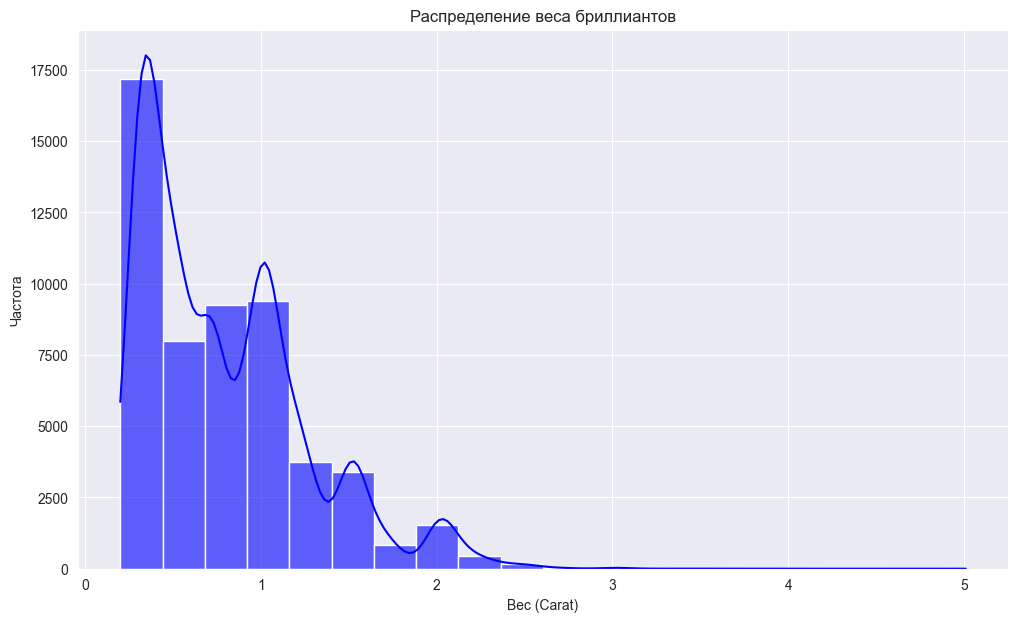

In [97]:
# Построение гистограммы веса (carat)
plt.figure(figsize=(12, 7))
sns.histplot(df_origin['carat'], bins=20, kde=True, color="blue", alpha=0.6, kde_kws={'bw_adjust': 1.5})
plt.xlabel('Вес (Carat)')
plt.ylabel('Частота')
plt.title('Распределение веса бриллиантов')
plt.grid(True)
plt.show()

График показывает распределение веса бриллиантов. Видно, что большинство камней имеют небольшой вес (до 1 карата), а частота встречаемости уменьшается с увеличением веса. Распределение имеет выраженный правый хвост, что говорит о редкости крупных бриллиантов.

### Качество огранки

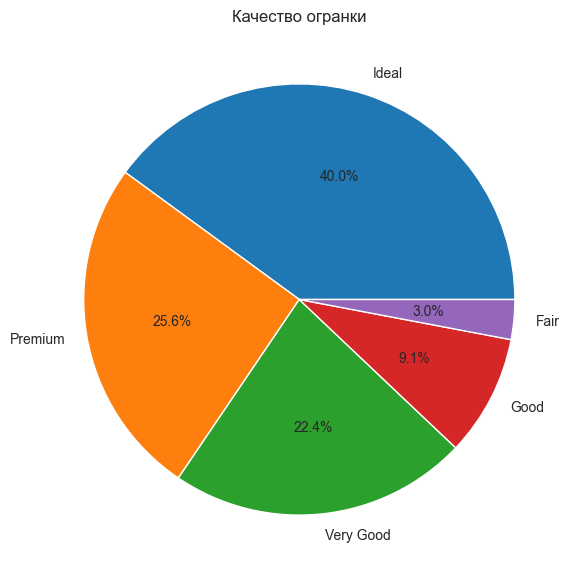

In [98]:
plt.figure(figsize=(12, 7))
plt.pie(df_origin['cut'].value_counts(), labels = df_origin['cut'].value_counts().index, autopct="%1.1f%%")
plt.title("Качество огранки")
plt.show()

Большая часть бриллиантов имеет огранку категории Ideal (40%), что говорит о высоком качестве обработки камней. Следующими по распространенности идут Premium (25.6%) и Very Good (22.4%). Категории Good (9.1%) и Fair (3.0%) встречаются значительно реже, что указывает на то, что бриллианты с менее качественной огранкой составляют небольшую долю.

### Прозрачность

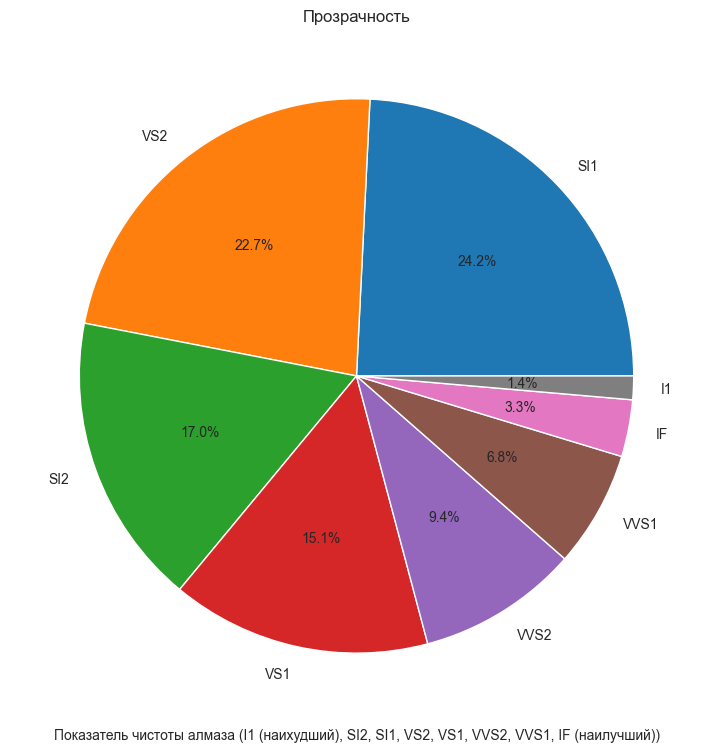

In [99]:
plt.figure(figsize=(12, 9))
plt.pie(df_origin['clarity'].value_counts(), labels = df_origin['clarity'].value_counts().index, autopct="%1.1f%%")
plt.title("Прозрачность")
plt.xlabel("Показатель чистоты алмаза (I1 (наихудший), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (наилучший))")
plt.show()

Наиболее распространенные категории прозрачности — SI1 (24.2%) и VS2 (22.7%). Достаточно часто встречаются SI2 (17.0%) и VS1 (15.1%). Бриллианты с высокой прозрачностью (VVS2, VVS1 и IF) составляют меньшую долю, а категория I1, относящаяся к наименее прозрачным камням, занимает всего 1.4%.

### Цвет

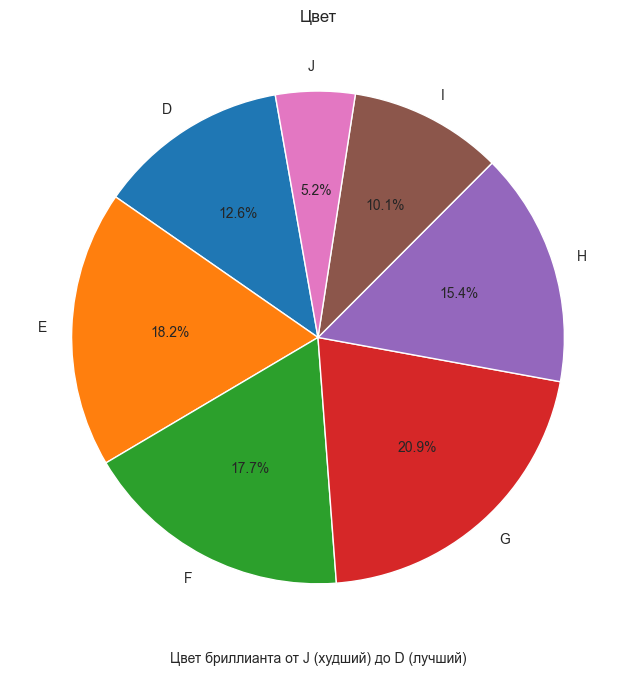

In [100]:
plt.figure(figsize=(12, 8))
color_counts = df_origin['color'].value_counts().sort_index()
plt.pie(color_counts, labels=color_counts.index, autopct="%1.1f%%", startangle=100)
plt.title("Цвет")
plt.xlabel("Цвет бриллианта от J (худший) до D (лучший)")
plt.show()

Самые распространенные цвета — G (20.9%), E (18.2%) и F (17.7%), что означает, что большинство бриллиантов имеют высокое качество цвета с минимальными оттенками желтизны. Реже встречаются камни с цветами H (15.4%), I (10.1%) и J (5.2%), которые имеют более выраженный желтоватый оттенок.

### Общая глубина в процентах

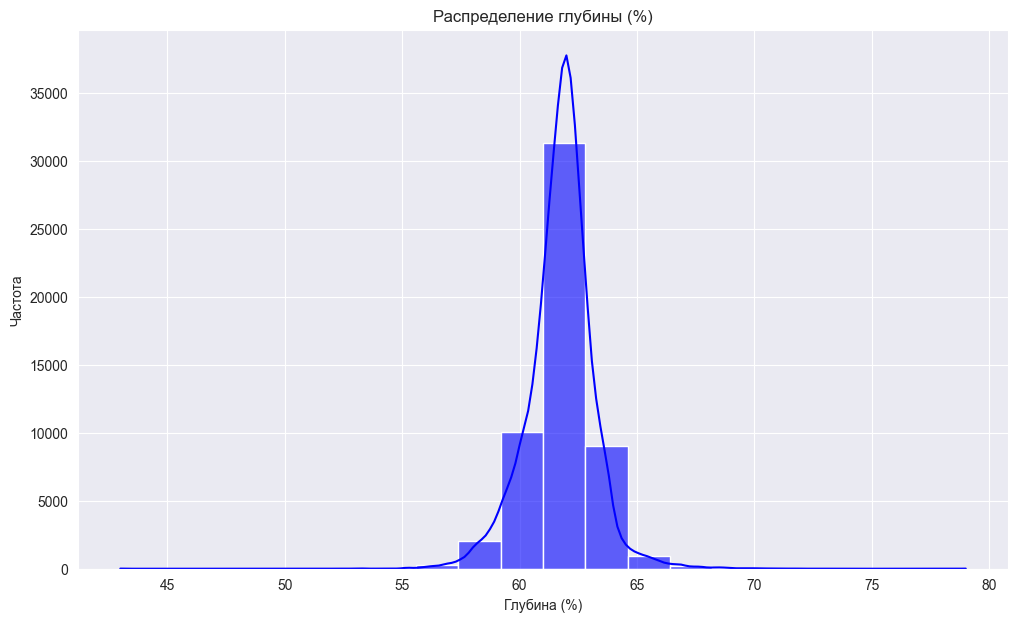

In [101]:
plt.figure(figsize=(12, 7))
sns.histplot(df_origin['depth'], bins=20, kde=True, color='blue', alpha=0.6)
plt.title("Распределение глубины (%)")
plt.xlabel("Глубина (%)")
plt.ylabel("Частота")
plt.show()

Глубина в большинстве случаев находится в пределах 59–61%, распределение близко к нормальному, а редкие выбросы за пределами 65% встречаются редко.

### Ширина вершины ромба относительно самой широкой точки

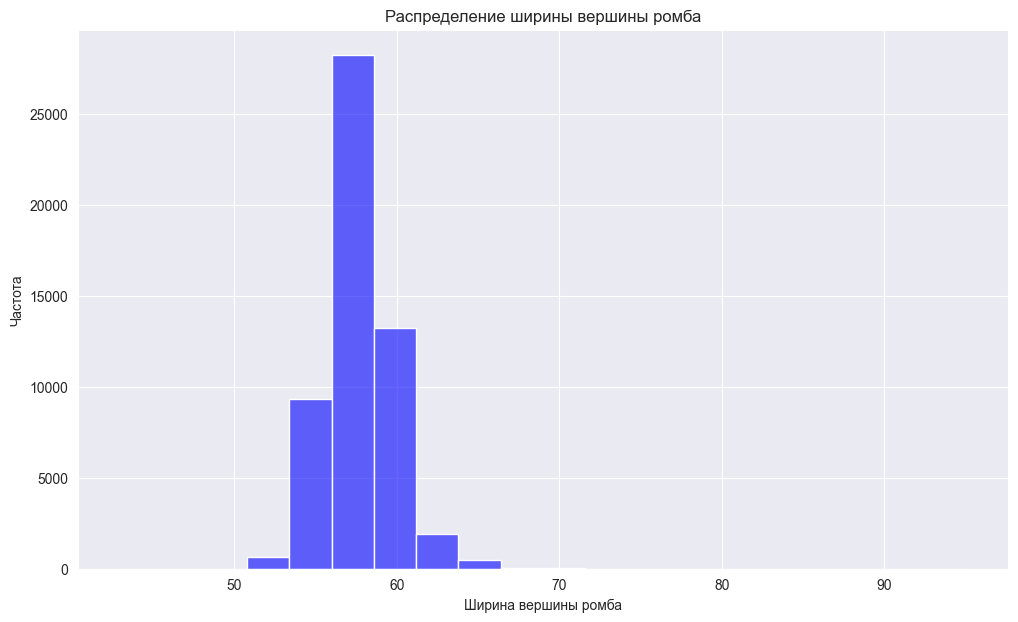

In [102]:
plt.figure(figsize=(12, 7))
sns.histplot(df_origin['table'], bins=20, color='blue', alpha=0.6)
plt.title("Распределение ширины вершины ромба")
plt.xlabel("Ширина вершины ромба")
plt.ylabel("Частота")
plt.show()

Ширина вершины ромба сосредоточена в диапазоне 57–58, распределение слабо асимметрично, но больших отклонений почти нет.

### Стоимость

#### Гистограмма

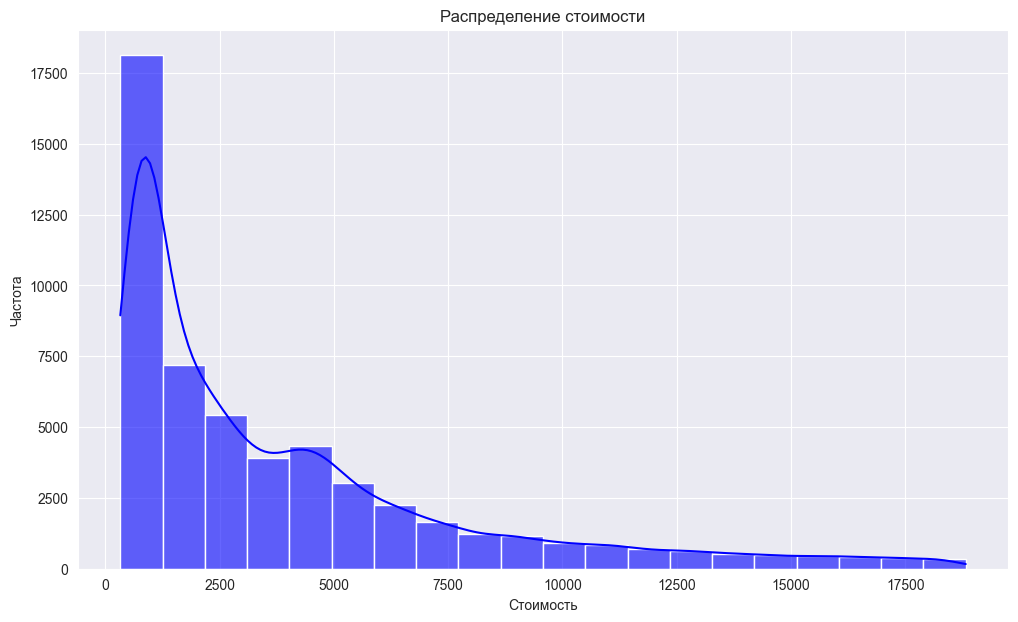

In [103]:
plt.figure(figsize=(12, 7))
sns.histplot(df_origin['price'], bins=20, kde=True, color='blue', alpha=0.6)
plt.title("Распределение стоимости")
plt.xlabel("Стоимость")
plt.ylabel("Частота")
plt.show()

Распределение стоимости имеет выраженный пик в нижнем диапазоне, большая часть бриллиантов стоит относительно недорого. Длинный хвост вправо указывает на наличие редких, но значительно более дорогих экземпляров, что свидетельствует о сильной неравномерности в ценах.

#### Цена в зависимости от цвета

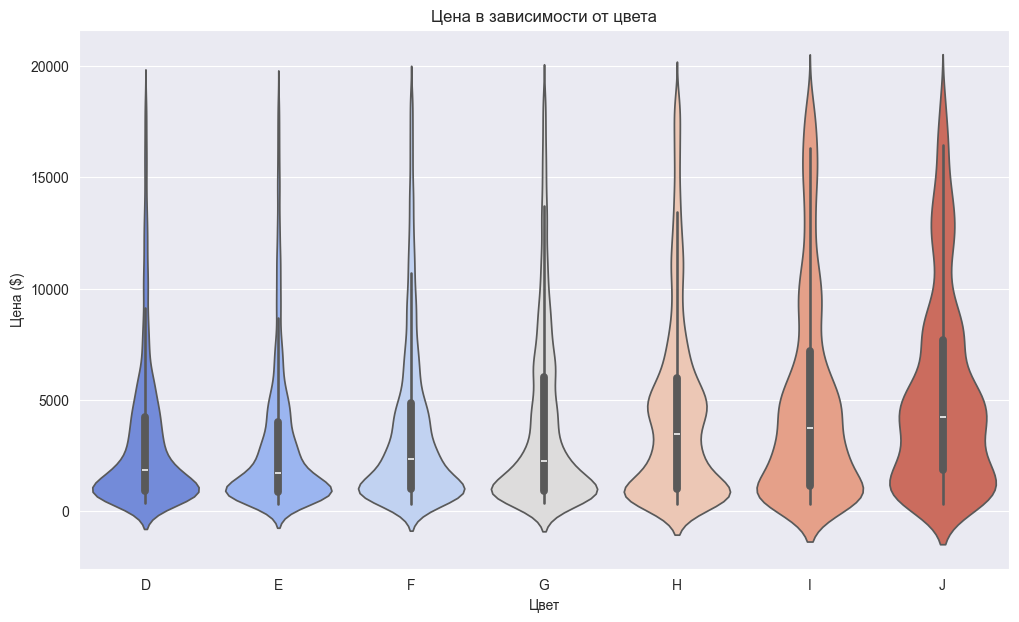

In [104]:
plt.figure(figsize=(12, 7))
color_order = sorted(df_origin['color'].unique())  # Указываем порядок цветов
sns.violinplot(x=df_origin['color'], y=df_origin['price'], palette="coolwarm", order=color_order)
plt.title("Цена в зависимости от цвета")
plt.xlabel("Цвет")
plt.ylabel("Цена ($)")
plt.show()

Наибольшие медианные цены наблюдаются у бриллиантов с цветом D, E и F, что подтверждает их высокое качество и меньший оттенок желтизны. По мере движения к цветам H, I и J цены снижаются, но наблюдаются выбросы с высокой стоимостью, что говорит о влиянии других факторов, таких как огранка и прозрачность.

#### Цена в зависимости от качества огранки

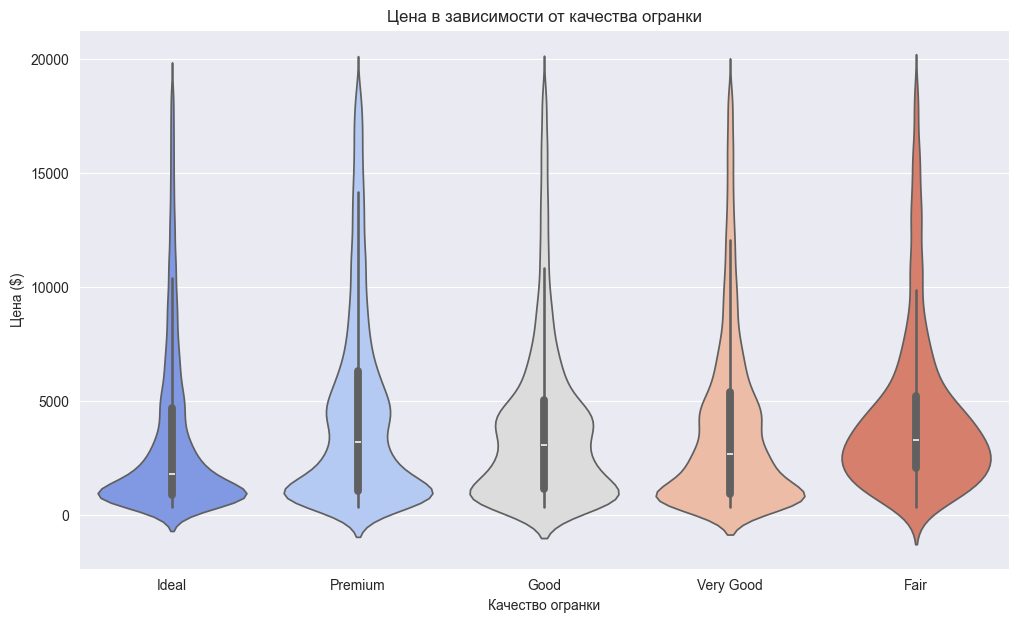

In [105]:
plt.figure(figsize=(12, 7))
sns.violinplot(x=df_origin['cut'], y=df_origin['price'], palette="coolwarm")
plt.title("Цена в зависимости от качества огранки")
plt.xlabel("Качество огранки")
plt.ylabel("Цена ($)")
plt.show()

Бриллианты с огранкой Ideal и Premium имеют схожий диапазон цен, но Premium демонстрирует чуть более высокие значения. Камни с огранкой Good и Fair в среднем дешевле, хотя наблюдаются отдельные дорогие экземпляры, что может объясняться их крупным размером или высокой прозрачностью.

#### Средняя цена по качеству огранки

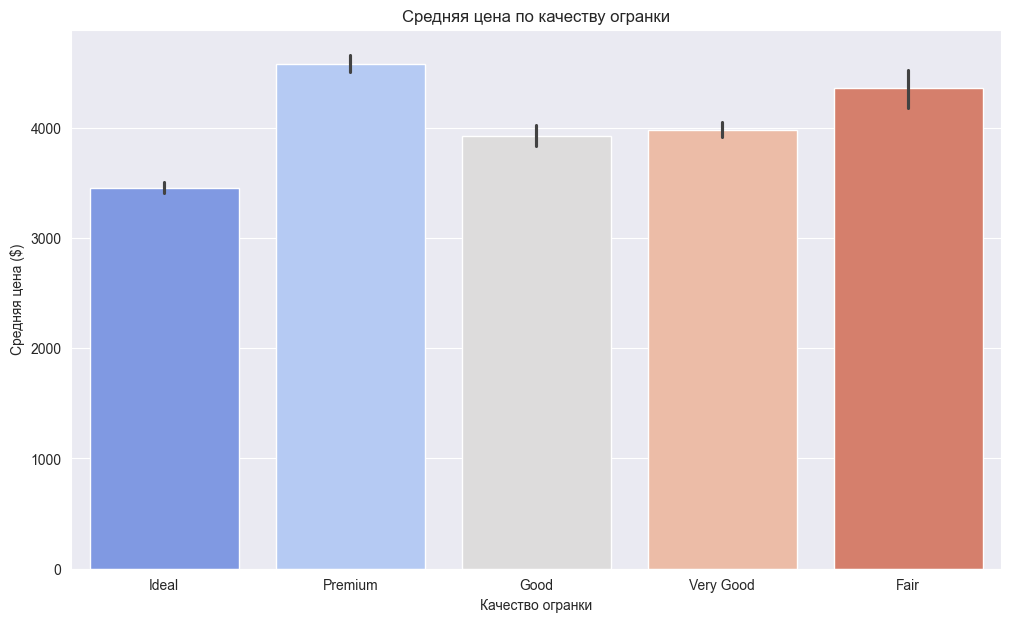

In [106]:
plt.figure(figsize=(12, 7))
sns.barplot(x=df_origin['cut'], y=df_origin['price'], estimator=lambda x: x.mean(), palette="coolwarm")
plt.title("Средняя цена по качеству огранки")
plt.xlabel("Качество огранки")
plt.ylabel("Средняя цена ($)")
plt.show()

Наибольшая средняя стоимость у бриллиантов с огранкой Premium, что указывает на их высокую ценность. Несмотря на то, что Ideal считается лучшей по качеству, её средняя цена ниже, скорее всего из-за небольши размеров. Огранка Fair, хоть и относится к менее качественным, имеет одну из самых высоких средних цен, что может быть связано с размером камней в этой категории.

## 4. Проверка на наличие выбросов и аномалий, при необходимости — обработка или удаление



### Функция для расчета границ выбросов




In [107]:
def get_outliers(df, column, coef=1.5):
    Q1 = df[column].quantile(0.25)  # Первый квартиль (25%)
    Q3 = df[column].quantile(0.75)  # Третий квартиль (75%)
    IQR = Q3 - Q1  # Межквартильный размах

    lower_bound = Q1 - coef * IQR
    upper_bound = Q3 + coef * IQR


    return lower_bound, upper_bound

### Вес бриллианта (carat)

In [108]:
df_origin['carat'].mean()

np.float64(0.7978793666098049)

In [109]:
lower_carat, upper_carat = get_outliers(df_origin, 'carat')
lower_carat, upper_carat

(np.float64(-0.5599999999999999), np.float64(2.0))

In [110]:
lower_carat, upper_carat

(np.float64(-0.5599999999999999), np.float64(2.0))

### Глубина (depth)

In [111]:
lower_depth, upper_depth = get_outliers(df_origin, 'depth')
lower_depth, upper_depth

(np.float64(58.75), np.float64(64.75))

### Ширина вершины ромба  (table)


In [112]:
lower_table, upper_table = get_outliers(df_origin, 'table')
lower_table, upper_table

(np.float64(51.5), np.float64(63.5))

In [113]:
lower_price, upper_price = get_outliers(df_origin, 'price')
lower_price, upper_price

(np.float64(-5611.625), np.float64(11885.375))

### Длина (x)


In [114]:
lower_x, upper_x = get_outliers(df_origin, 'x')
lower_x, upper_x

(np.float64(1.9649999999999999), np.float64(9.285))

### Ширина (y)


In [115]:
lower_y, upper_y = get_outliers(df_origin, 'y')
lower_y, upper_y

(np.float64(1.9899999999999993), np.float64(9.27))

### Глубина (z)


In [116]:
lower_z, upper_z = get_outliers(df_origin, 'z')
lower_z, upper_z

(np.float64(1.2150000000000003), np.float64(5.734999999999999))

### Удаление

In [117]:
df_origin = df_origin[
    (df_origin['carat'] > 0) &
    (df_origin['price'] > 0)
].copy()

In [118]:
# df_cleaned = df_origin[
#     (df_origin['carat'].between(lower_carat, upper_carat)) &
#     (df_origin['depth'].between(lower_depth, upper_depth)) &
#     (df_origin['table'].between(lower_table, upper_table)) &
#     (df_origin['x'].between(lower_x, upper_x)) &
#     (df_origin['y'].between(lower_y, upper_y)) &
#     (df_origin['z'].between(lower_z, upper_z))
# ]

## 5. Анализ категориальных признаков и выбор способа кодирования

(Label Encoding)

In [119]:
df = df_origin.copy()

### Cut (качество огранки)

In [120]:
cut_mapping = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
df['cut_encoded'] = df['cut'].map(cut_mapping)

In [121]:
df.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z,cut_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,4
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,2


### color (цвет бриллианта)

In [122]:
color_mapping = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
df['color_encoded'] = df['color'].map(color_mapping)

In [123]:
df.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z,cut_encoded,color_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5,6
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,4,6
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,2,6


### clarity (Прозрачность)

In [124]:
clarity_mapping = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}
df['clarity_encoded'] = df['clarity'].map(clarity_mapping)

In [125]:
df.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5,6,2
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,4,6,3
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,2,6,5


## 6. Визуализация зависимостей между признаками


### Зависимость цены и веса, в разделении по цветам

In [126]:
unique_colors = sorted(df["color"].unique())
unique_colors

['D', 'E', 'F', 'G', 'H', 'I', 'J']

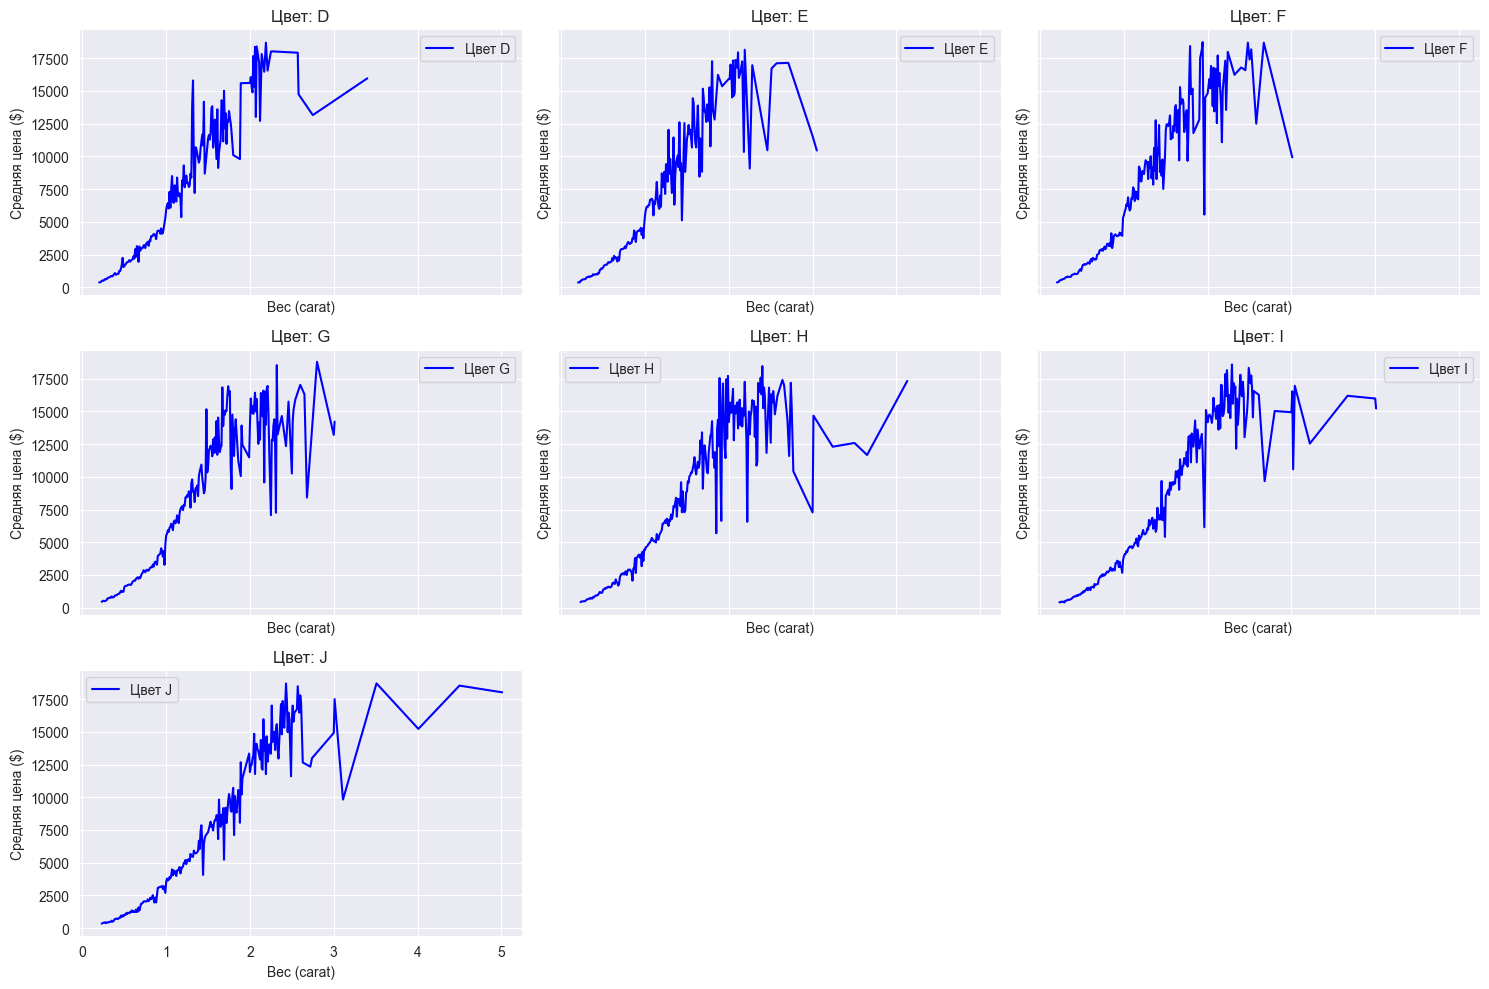

In [127]:
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 10), sharex=True, sharey=True)

# Проходим по каждому цвету и строим графики
for i, color in enumerate(unique_colors):
    row, col = divmod(i, cols)  # Вычисляем позицию в сетке
    subset = df[df["color"] == color].groupby("carat")["price"].mean().reset_index()
    axes[row, col].plot(subset["carat"], subset["price"], color="blue", linestyle="-", label=f"Цвет {color}")

    axes[row, col].set_title(f"Цвет: {color}")
    axes[row, col].set_ylabel("Средняя цена ($)")
    axes[row, col].set_xlabel("Вес (carat)")

    axes[row, col].legend()
    axes[row, col].grid(True)

# Убираем пустые графики, если цветов меньше, чем ячеек
for i in range(len(unique_colors), rows * cols):
    row, col = divmod(i, cols)
    fig.delaxes(axes[row, col])


plt.tight_layout()
plt.show()

 Видно, что для всех цветов с увеличением веса цена растёт, но на больших значениях наблюдаются колебания. Дорогие экземпляры присутствуют во всех категориях, но максимальные цены чаще встречаются у бриллиантов с цветами D, E и F. Более жёлтые оттенки (H, I, J) в целом дешевле, но всё же имеют дорогие экземпляры, что может быть связано с другими характеристиками, такими как качество огранки или прозрачность.

### Зависимость веса (carat) и размеры сторон (x, y, z)

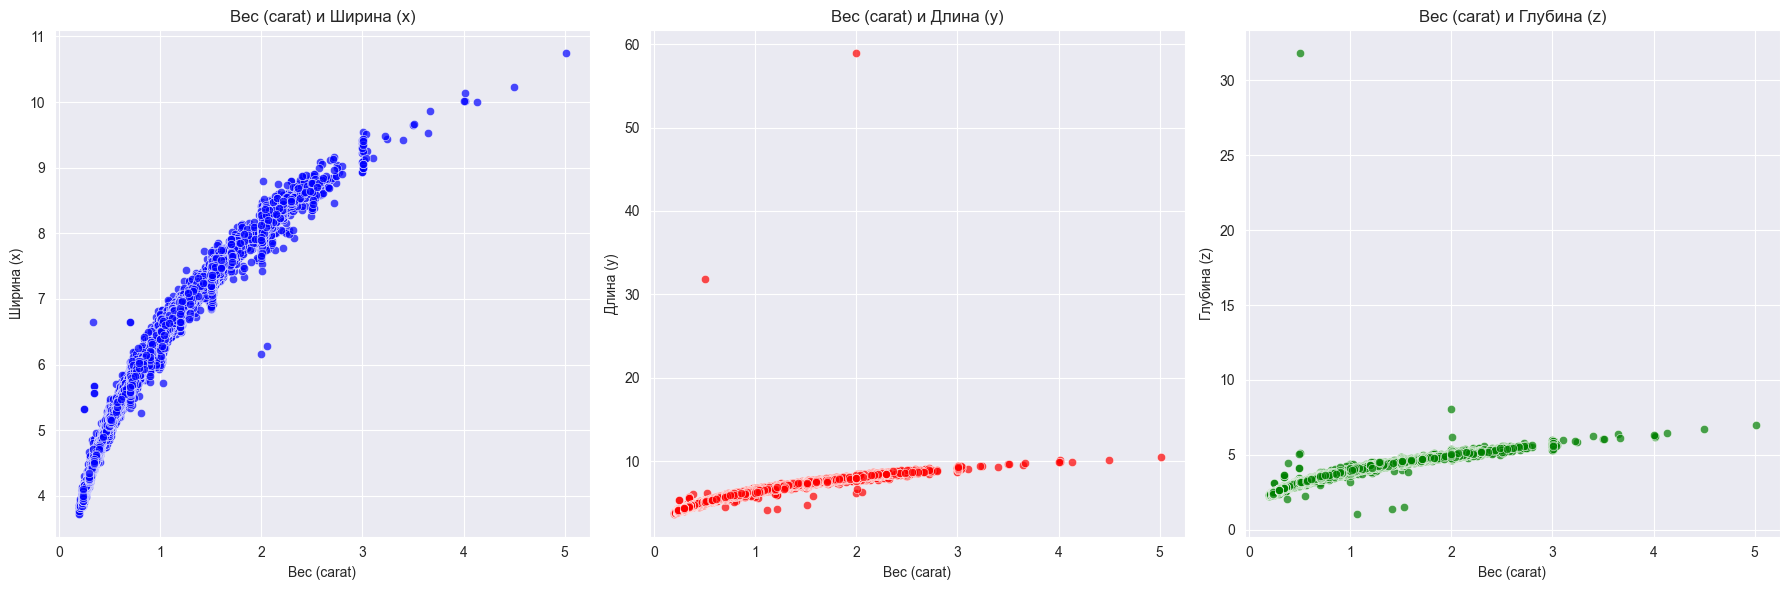

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# График carat vs x
sns.scatterplot(data=df, x="carat", y="x", color="blue", alpha=0.7, ax=axes[0])
axes[0].set_title("Вес (carat) и Ширина (x)")
axes[0].set_ylabel("Ширина (x)")
axes[0].grid(True)

# График carat vs y
sns.scatterplot(data=df, x="carat", y="y", color="red", alpha=0.7, ax=axes[1])
axes[1].set_title("Вес (carat) и Длина (y)")
axes[1].set_ylabel("Длина (y)")
axes[1].grid(True)

# График carat vs z
sns.scatterplot(data=df, x="carat", y="z", color="green", alpha=0.7, ax=axes[2])
axes[2].set_title("Вес (carat) и Глубина (z)")
axes[2].set_ylabel("Глубина (z)")
axes[2].grid(True)

# Общая подпись оси X
for ax in axes:
    ax.set_xlabel("Вес (carat)")

plt.tight_layout()
plt.show()

1. Вес vs. Ширина (x) (синий график, слева):

Наблюдается чёткая положительная зависимость между весом и шириной бриллиантов.
Чем больше вес, тем шире бриллиант, без резких выбросов.

2. Вес vs. Длина (y) (красный график, в центре):

В целом, зависимость положительная, но есть несколько выбросов, особенно один аномально длинный камень (~60).

3. Вес vs. Глубина (z) (зелёный график, справа):

Глубина тоже растёт с весом, но зависимость менее выражена.
Присутствуют несколько выбросов с аномально большой глубиной.

Видно экспонененциальную зависимость

### Зависимоть цены и размеры сторон (x, y, z)

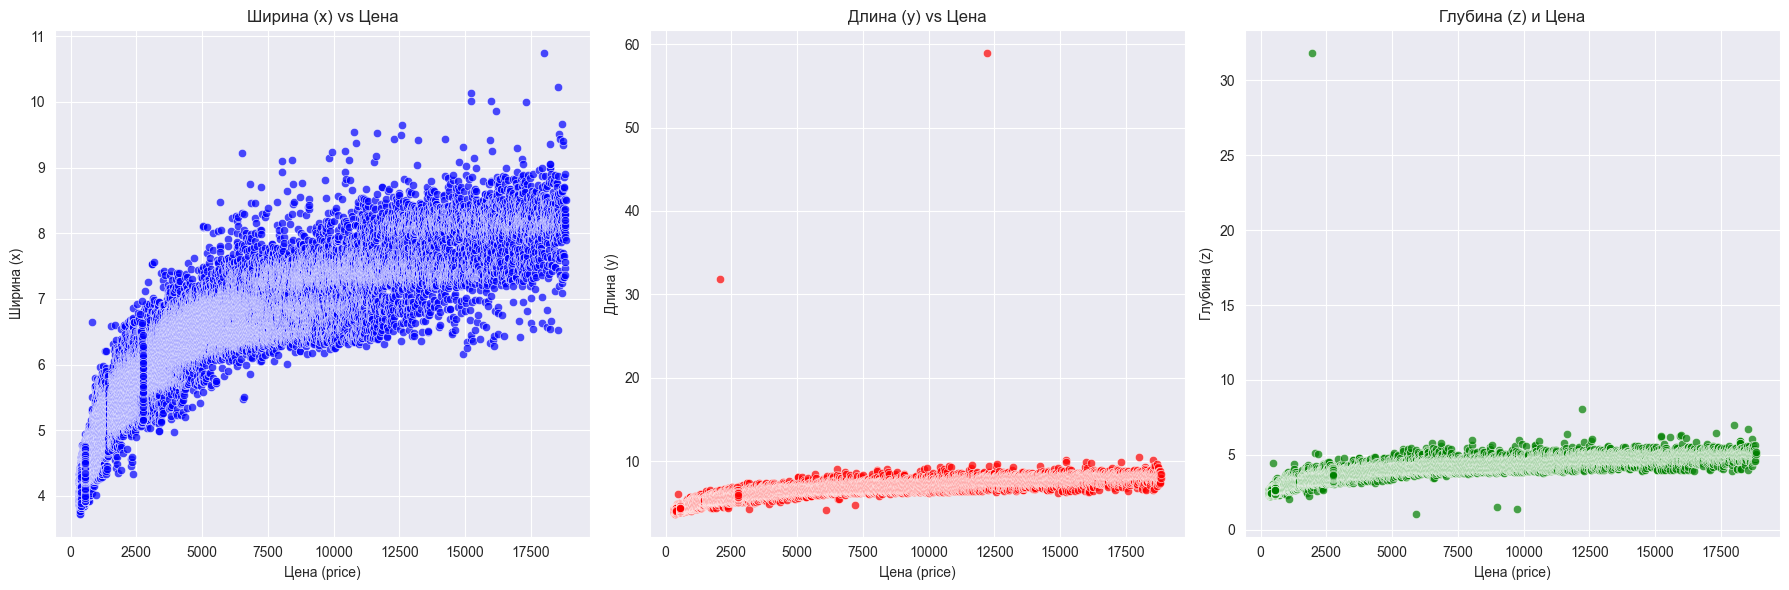

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# График x vs cut
sns.scatterplot(data=df, x="price", y="x", color="blue", alpha=0.7, ax=axes[0])
axes[0].set_title("Ширина (x) vs Цена")
axes[0].set_ylabel("Ширина (x)")
axes[0].grid(True)

# График y vs cut
sns.scatterplot(data=df, x="price", y="y", color="red", alpha=0.7, ax=axes[1])
axes[1].set_title("Длина (y) vs Цена")
axes[1].set_ylabel("Длина (y)")
axes[1].grid(True)

# График z vs cut
sns.scatterplot(data=df, x="price", y="z", color="green", alpha=0.7, ax=axes[2])
axes[2].set_title("Глубина (z) и Цена")
axes[2].set_ylabel("Глубина (z)")
axes[2].grid(True)

# Поворачиваем подписи оси X для удобства
for ax in axes:
    ax.set_xlabel("Цена (price)")

plt.tight_layout()
plt.show()

1. Ширина (x) vs Цена (синий график, слева). В целом наблюдается положительная зависимость: с ростом цены увеличивается ширина. Однако после определённого порога цена может расти независимо от ширины. Видно значительное скопление точек в средней части, что указывает на популярные размеры.

2. Длина (y) vs Цена (красный график, в центре). Аналогичная тенденция: чем выше цена, тем больше длина. Есть выбросы, особенно один экстремально длинный бриллиант (~60), который явно аномален.

3. Глубина (z) vs Цена (зелёный график, справа). Глубина слабо коррелирует с ценой, распределение более равномерное. Есть несколько выбросов, но основная масса данных сосредоточена в узком диапазоне.

## 7. "Тепловая карта" зависимости признаков.


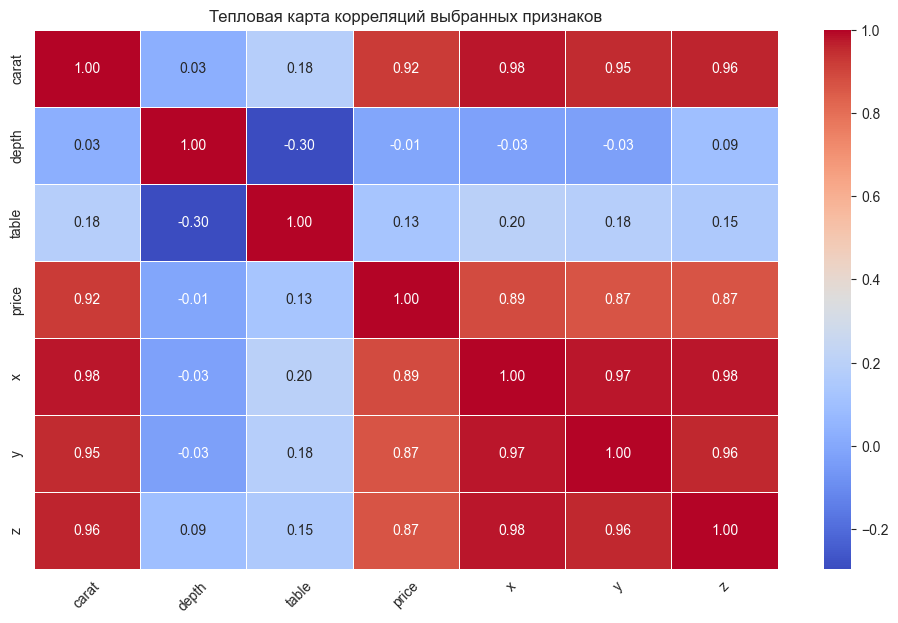

In [130]:
selected_columns = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
df_selected = df[selected_columns]

plt.figure(figsize=(12, 7))
sns.heatmap(df_selected.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.xticks(rotation=45)
plt.title("Тепловая карта корреляций выбранных признаков")
plt.show()




*   "Сarat" (вес бриллианта) сильно коррелирует с "price" и линейными размерами "x", "y", "z", что логично — большие бриллианты дороже.
*   "Depth" и "table" слабо связаны с ценой и размерами, а их отрицательная корреляция говорит о слабом влиянии на цену.



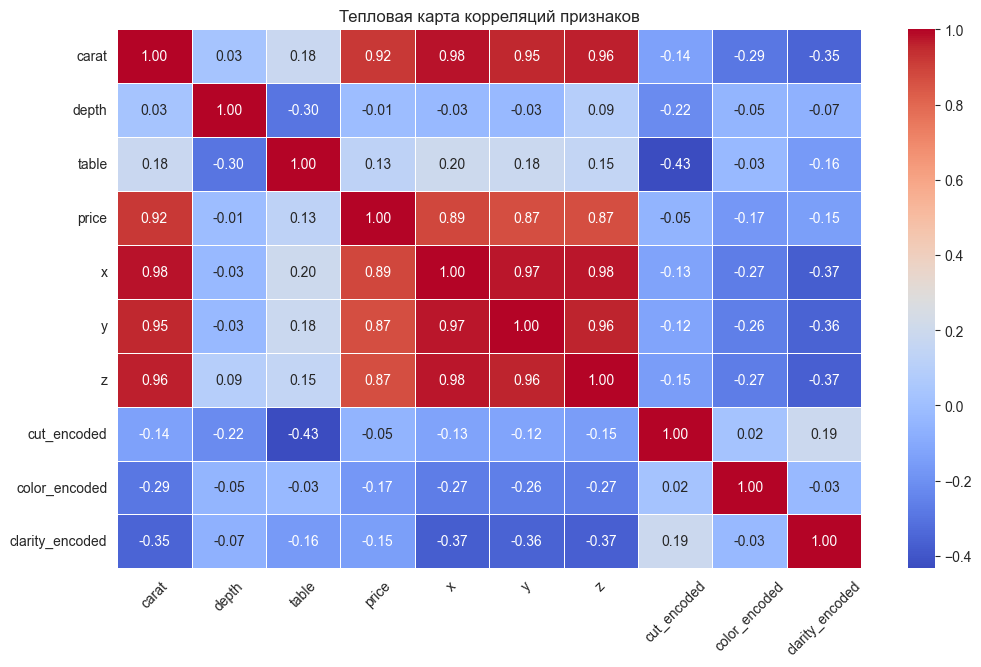

In [131]:
df_colums = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 7))
sns.heatmap(df_colums.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.xticks(rotation=45)
plt.title("Тепловая карта корреляций признаков")
plt.show()

## 8. Отделение целевого признака (цены) и разбиение данных на обучающую и тестовую выборки

In [132]:
df.drop("cut", axis=1, inplace=True)

In [133]:
df.drop("color", axis=1, inplace=True)

In [134]:
df.drop("clarity", axis=1, inplace=True)

In [135]:
df.head()

,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,0.23,61.5,55.0,326,3.95,3.98,2.43,5,6,2
1,0.21,59.8,61.0,326,3.89,3.84,2.31,4,6,3
2,0.23,56.9,65.0,327,4.05,4.07,2.31,2,6,5
3,0.29,62.4,58.0,334,4.20,4.23,2.63,4,2,4
4,0.31,63.3,58.0,335,4.34,4.35,2.75,2,1,2


### Отделяем целевой признак

In [136]:
X = df.drop(columns=['price'])
y = df['price']

### Разбиваем набор данных на тренировочную и тестовую выборки.

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% на тест
    shuffle=True,
    random_state=42
)

## Нормализация признаков

In [138]:
# Нормализация только на тренировочных данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Модель линейной регрессии

In [139]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'R2: {r2:.4f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {mse ** 0.5:.2f}')
print(f'MAPE: {mape * 100:.2f}%')

R2: 0.9069
MSE: 1444441.67
RMSE: 1201.85
MAPE: 43.64%


R2: 0.9069

MSE: 1444441.67

RMSE: 1201.85

MAPE: 43.64%

## Полиноминальная регрессия разных степеней

In [140]:
for degree in range(1, 5):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f'Degree {degree}:')
    print(f'R2: {r2:.4f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {mse ** 0.5:.2f}')
    print(f'MAPE: {mape * 100:.2f}%')
    print('\n')

Degree 1:
R2: 0.9069
MSE: 1444441.67
RMSE: 1201.85
MAPE: 43.64%


Degree 2:
R2: 0.8494
MSE: 2337834.97
RMSE: 1529.00
MAPE: 19.50%


Degree 3:
R2: -619.7526
MSE: 9633716200.40
RMSE: 98151.50
MAPE: 56.38%


Degree 4:
R2: -10790999.5691
MSE: 167469992663019.47
RMSE: 12941019.77
MAPE: 6016.50%




Degree 1:

R2: 0.9069

MSE: 1444441.67

RMSE: 1201.85

MAPE: 43.64%


## Cобственная реализация линейной регрессии

In [141]:
class MySelfRergession:
    def __init__(self, start_lr=0.1, n_iter=10000):
        self.start_lr = start_lr
        self.n_iter = n_iter
        self.wt = None


    def fit(self, X_train: np.ndarray, y_train: pd.Series):
        """Обучение модели"""
        # делаем копии, чтобы не менять исходные данные
        X = X_train.copy()
        y = y_train.copy().values.reshape(-1, 1)

        n_samples, n_features = X.shape
        X = np.hstack([np.ones((n_samples, 1)), X])

        self.wt = np.zeros((n_features + 1, 1))

        for t in range(1, self.n_iter + 1):
            y_pred = X @ self.wt

            gradient = (2 / n_samples) * X.T @ (y_pred - y)

            lr = self.start_lr / t
            self.wt -= lr * gradient # "-" - антиградиент

    def predict(self, X_test: np.ndarray):
        if self.wt is None:
            raise ValueError("Модель ещё не обучена!")

        n_samples = X_test.shape[0]
        X = np.hstack([np.ones((n_samples, 1)), X_test])
        return X @ self.wt

## Тестирование

In [142]:
for lr in range(100, 900, 100):
    st = 0.01 * lr
    my_self_regression = MySelfRergession(start_lr=st)
    my_self_regression.fit(X_train_scaled, y_train)
    y_pred = my_self_regression.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f'start_lr {st}:')
    print(f'R2: {r2:.4f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {mse ** 0.5:.2f}')
    print(f'MAPE: {mape * 100:.2f}%')
    print('\n')

start_lr 1.0:
R2: 0.8946
MSE: 1636404.60
RMSE: 1279.22
MAPE: 53.70%


start_lr 2.0:
R2: 0.9029
MSE: 1507464.38
RMSE: 1227.79
MAPE: 48.55%


start_lr 3.0:
R2: 0.9052
MSE: 1471702.09
RMSE: 1213.14
MAPE: 46.40%


start_lr 4.0:
R2: 0.9060
MSE: 1458699.98
RMSE: 1207.77
MAPE: 45.39%


start_lr 5.0:
R2: 0.9064
MSE: 1452694.12
RMSE: 1205.28
MAPE: 44.85%


start_lr 6.0:
R2: 0.9065
MSE: 1451473.25
RMSE: 1204.77
MAPE: 44.64%


start_lr 7.0:
R2: -0.3356
MSE: 20728393.97
RMSE: 4552.84
MAPE: 208.88%


start_lr 8.0:
R2: -190699.8260
MSE: 2959564845751.33
RMSE: 1720338.58
MAPE: 67470.18%




start_lr 6.0:

R2: 0.9065

MSE: 1451473.25

RMSE: 1204.77

MAPE: 44.64%


## Собственная полиноминальная регрессия


In [145]:
    # for lr in range(100, 900, 100):
    #     st = 0.01 * lr
    #     model = Pipeline([
    #         ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    #         ('linear', MySelfRergession(start_lr=st))
    #     ])
    #
    #     model.fit(X_train_scaled, y_train)
    #     y_pred = model.predict(X_test_scaled)
    #
    #     r2 = r2_score(y_test, y_pred)
    #     mse = mean_squared_error(y_test, y_pred)
    #     mape = mean_absolute_percentage_error(y_test, y_pred)
    #
    #     print(f'start_lr {st}:')
    #     print(f'R2: {r2:.4f}')
    #     print(f'MSE: {mse:.2f}')
    #     print(f'RMSE: {mse ** 0.5:.2f}')
    #     print(f'MAPE: {mape * 100:.2f}%')
    #     print('\n')

start_lr 1.0:

R2: -237315433969854793770508882189406657493255806567113013861445731309910959082690433218204540974435005366272.0000

MSE: 3682996190308168982444641455968372104463743741122513120625110528758720844693870779274545047502636746086090276864.00

RMSE: 60687693895123163648221420944971577601479830607033794560.00

MAPE: 342932904623818146345322858502466703416414870429499392.00%

---


start_lr 2.0:

R2: -471603570718173343070221825249529511730725636581184057605351534557428741476822254635135798948391908073728066847035894653528526223006767580005227326062954751286424539341278417624642970476427369102885637755335386880464032964505879028830074577092608.0000

MSE: 7319010505281316071504780626561214800291423891173625510608876683086949368358301333699049329867892407231787461382965944563236533262408524860044008568998378373976408306123075861715954817318065395127763416940738373821337210225499014379874423273874557763584.00

RMSE: 2705366981627689685180038068023172131772515896231339459018444452432602534847787981295784146697301386552523943709223467215749120.00

MAPE: 17562461805592922946143051415920840282549751300025539588415041182539813335550547712604197578325040979984582844394657200209920.00%


In [147]:
    # for lr in range(10, 90, 10):
    #     st = 0.01 * lr
    #     model = Pipeline([
    #         ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    #         ('linear', MySelfRergession(start_lr=st))
    #     ])
    #
    #     model.fit(X_train_scaled, y_train)
    #     y_pred = model.predict(X_test_scaled)
    #
    #     r2 = r2_score(y_test, y_pred)
    #     mse = mean_squared_error(y_test, y_pred)
    #     mape = mean_absolute_percentage_error(y_test, y_pred)
    #
    #     print(f'start_lr {st}:')
    #     print(f'R2: {r2:.4f}')
    #     print(f'MSE: {mse:.2f}')
    #     print(f'RMSE: {mse ** 0.5:.2f}')
    #     print(f'MAPE: {mape * 100:.2f}%')
    #     print('\n')

start_lr 0.1:

R2: 0.9064

MSE: 1453179.97

RMSE: 1205.48

MAPE: 43.02%

---

start_lr 0.2:

R2: 0.9397

MSE: 935567.66

RMSE: 967.25

MAPE: 31.71%

---

start_lr 0.3:

R2: -681498.5830

MSE: 10576473371523.31

RMSE: 3252149.04

MAPE: 29571.83%

---

start_lr 0.4:

R2: -58331033878596730880.0000

MSE: 905263395464189993004564480.00

RMSE: 30087595375240.44

MAPE: 446241429772.25%


## Сравнение результатов

| Модель                                             | R²         | MSE            | RMSE       | MAPE   |
| -------------------------------------------------- | ---------- | -------------- | ---------- | ------ |
| Линейная (sklearn)                                 | 0.9069     | 1 444 441.67   | 1201.85    | 43.64% |
| Полиномиальная (Degree 1)                          | 0.9069     | 1 444 441.67   | 1201.85    | 43.64% |
| Полиномиальная (Degree 2)                          | 0.8494     | 2 337 834.97   | 1529.00    | 19.50% |
| Линейная (собственная реализация)                  | 0.9065     | 1 451 473.25   | 1204.77    | 44.64% |
| Полиномиальная (2 степень, собственная реализация) | **0.9397** | **935 567.66** | **967.25** | 31.71% |
